# Building a simulation of a 2D drone

## Setup
Create a conda environment using

`conda create -n 2ddrone -c conda-forge pygame stable-baselines3 ipykernel jupyterlab matplotlib`

You can then open this jupyter notebook in jupyter lab or VS code.  In VS code, you should be able to choose the 2ddrone environment on the top right.

## Using a python class to simulate a simple ball in 2D
The ball should be subjected to gravity, therefore it is subject to a force towards negative `y` that is the same as its mass.

### Define a python class of the object to be simulated

In [ ]:
import numpy as np

class Ball:
    def __init__(self, x, y, mass):
        
        # Object parameters (will not change)
        self.mass = mass # in [kg]

        # State variables (these will change during the life of the object)
        self.x = x # in [m]
        self.y = y
        self.vx = 0 # in [m/s]
        self.vy = 0

    def step(self, dt):
        ''' steps the simulation of this ball. dt is in seconds '''

        # Forces are represented in Newtons. 
        fx = 0
        fy = -9.81 * self.mass
        ax = fx / self.mass
        ay = fy / self.mass
        self.vx = self.vx + ax * dt
        self.vy = self.vy + ay * dt
        self.x = self.x + self.vx * dt
        self.y = self.y + self.vy * dt

### Use the python class defined above
How long does a ball fall in 1 second?
Note that we are simulating 100 timesteps of 0.01 seconds each.

In [ ]:
b = Ball(0, 0, 1) # create a 1kg ball in (0,0)
dt = 0.01
t = 0
while t < 1:
    b.step(dt)
    t += dt
b.y

### Exercise 1.1
How much does the ball fall in 5 seconds?

### Exercise 1.2
Try using a different simulation step `dt`, e.g. 0.1 s or 0.00001 s. Does the result change? Explain why.

From now on, let's use a `dt` of 0.01 s, which seems to be pretty fine

### Exercise 1.3
Define an initial velocity to the ball by modifying its constructor to
`def __init__(self, x, y, vx, vy, mass):`

Consider a ball that starts at x=0, y=1, with a velocity of 2 m/s pointing at an elevation of 60 degrees to the top right.

Answer the following questions:
- what is the initial value of `vx` and `vy`?
- what is the `x` and `y` coordinates of the ball after 1, 2 and 3 seconds?
- run a simulation for 3 seconds, and save five numpy arrays (or a pandas dataframes with 5 columns, reporting the state variables of the ball -- position and velocity -- and the timestep)
- use matplotlib to plot the `x` coordinate vs time, and the `y` coordinate vs time. The time should be on the `x` axis of the plot, and should be expressed in seconds.
- use matplotlib to plot the trajectory of the ball in the `xy` plane

### Exercise 1.3 b

Consider 15 different balls, all launched from x=0, y=0, with a velocity of 5 m/s, pointing at different elevations (in degrees): 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80.

Simulate the trajectory of all balls until they hit the ground (i.e. its y coordinate drops below 0).

Draw the trajectories in the xy plane with differently colored curves.  Make sure you use `ax.set_aspect("equal")` so that the x and y coordinates have the same scale.  Verify that the ball that travels farthest away is the one launched at 45 degrees.

## Use pygame to visualize the simulation in real time
The `pygame_test.py` file uses pygame to instantiate a Drone object (as defined in `drone.py`) and visualize it in real time. Right now the drone is the same as the ball defined above.

Open a terminal, make sure the proper environment is activated (`conda activate 2ddrone`), and run `python pygame_test.py`.

Note that the Drone class includes a method to draw the drone on a pygame surface.  Understand how the method works

## Build the simulation of a drone with a thruster

### Exercise 1.4

Modify `drone.py` such that the Drone is drawn as an horizontal rectangle with a width of 50 cm and an height of 20 cm.  For now, we assume that the drone can not rotate and is always upright.

### Exercise 1.5

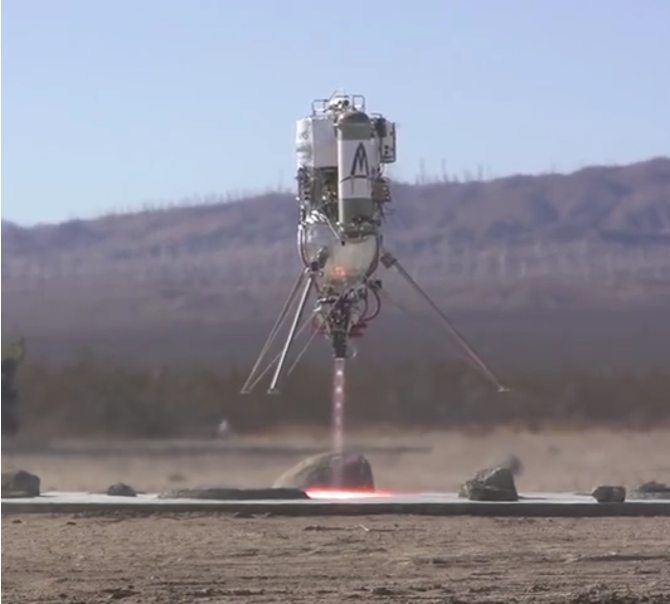

Masten Space Systems -- Xoie hovering rocket robot ([video](https://youtu.be/Rn6xIfY_3zM))


Let's modify our drone such that we add a *control variable*.  The drone has a single thruster on its bottom that can exert a maximum upwards force of 20 Newtons.

Change `drone.py` as follows:
- add a parameter to the constructor (i.e. the `__init__()` function) that represents the maximum thrust (which is a force, measured in Newtons) of the thruster.  Let's say default it to 20 N (which can lift approx 2 kg).  Save it to `self`, just like you did to the mass.
- add a parameter to the `Drone.step(self, dt)` that becomes `Drone.step(self, thrust, dt)` function that represents the thrust that the thruster is exerting in this timestep. Let's represent it as a number from 0 (no thrust) to 1 (maximum thrust).
- in the body of `step`, take this force into account when you compute the resultant force `fx` and `fy` (which are represented in Newtons)
- keep track of the last value of the thrust control variable by saving it to a variable `self.thrust`. We are only going to use this variable for drawing.
- modify `pygame_test` such that when you press the `w` key, the thruster is fired at maximum power, otherwise it is not fired.
- run the simulation and see if it works.

Experiment with the following:
- What happens to the horizontal component of the velocity of the drone that you are simulating? Do you have a way to change it when controlling the drone?

### Exercise 1.6

We would like to have visual feedback in our simulation of the amount of thrust. Modify `Drone.drawOnSurface` to draw a yellow triangle (or yellow line) pointing downwards from your drone (representing "fire"), with a length proportional to the thrust the drone is exerting. Look into the documentation of [pygame.draw](https://www.pygame.org/docs/ref/draw.html).

Try your simulation again.

### Exercise 1.7

Modify `pygame_test` in such a way that every time you press SPACE (once per keypress) you instantiate a new drone at coordinates (0,0) moving 1m/s in a random direction.  Instead of a single drone, you'll have to keep track of a variable-length list of drones. You'll have to draw them all, and step them all in your main loop.

When you press the E key (KEYDOWN event), remove all simulated drones.

### Exercise 1.8

Let's now handle the rotation of the drone in the 2D plane.

We'll need two new state variables:
- The drone angle `theta`.  It is an angle, in radians, such that 0 means that the drone is upright, 1 means that it is rotated 1 radians counterclockwise, pi/2 means that it is rotated 90 degrees to the left, etc.
- The drone angular velocity `omega`.  It is an angular velocity, in radians per second, such that 0 means that the drone is not rotating (but it could be not upright), 1 means that it is rotating 1 radians per second counterclockwise, etc.

Add these state variables to your `Drone` class, both in the constructor and in `step`. Note that in `step` you will need to update `theta` at each frame according to `omega`, but you currently have no way to update `omega`, which will not change during the simulation.  It is OK.

Initialize your drone with `theta=0` rotating at `omega = +1` radians/s, and simulate it for 5 seconds. Verify that the final rotation angle is 5 radians.  

### Exercise 1.9 (optional, you can skip this)

Now, modify the Drone class such that you draw your drone according to its rotation. The easiest way is to draw the drone as a circle with a given radius (say, 0.5 m), centered on its position, with a small line moving from the center of the drone to the top of the drone to indicate its direction.  You can draw the thrust as a line exiting from the opposite "side" of the drone.

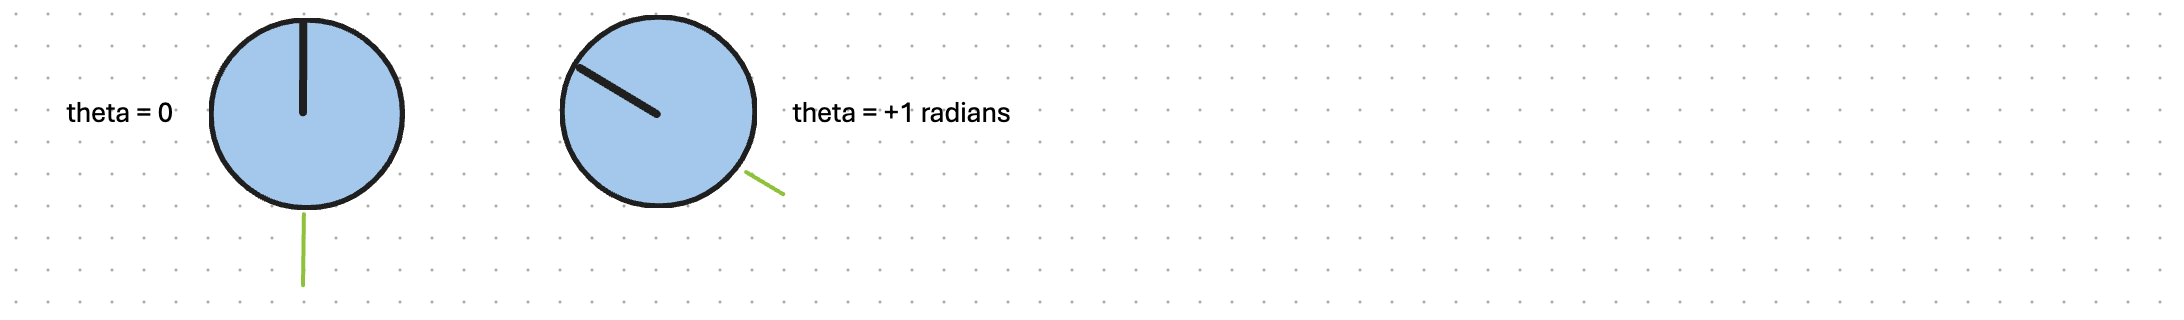

You can use the following functions of pygame.draw:
- [circle](https://www.pygame.org/docs/ref/draw.html#pygame.draw.circle)
- [line](https://www.pygame.org/docs/ref/draw.html#pygame.draw.line)

For example, if my drone is at x,y and oriented as theta, with a radius of r, the "up" line should be drawn between points:
- $x$, $y$
- $x - r \cdot \sin(\theta)$, $y + r \cdot \cos(\theta)$

## Simulating the physics of a rotating drone with a single thruster

Test your drawing functions by running your simulation as follows:
- Create a drone with `omega = 0`.  It should not rotate
- Create a drone with `omega = +1`.  It should rotate at approximately 60 degrees per second, clockwise.

Now, make sure that your step function is correctly simulating the physics of the thurster. Consider that, now that the drone has a rotation of `theta`, the thruster will exert a force both towards y and towards x. In particular, if $f$ is the total force of the thruster, we expect:
- fx = $- f \cdot \sin(\theta)$
- fy = $f \cdot \cos(\theta)$

Test your simulation with a drone rotating with `omega` = 3 rad/s.
Can you control it to keep hovering by just firing it in the correct moments?  What if you increase the maximum force of the thruster to 100 N?

## Properly drawing a rotated drone as a rotated polygon

We want to draw our drone as follows.  The drawing before defines 4 points of a polygon expressed in the field of reference of the drone in 2D (the shown axes).  Dots are spaced 5 cm.  The drone is 1 m wide and 20 cm tall.  Coordinates are reported in cm.

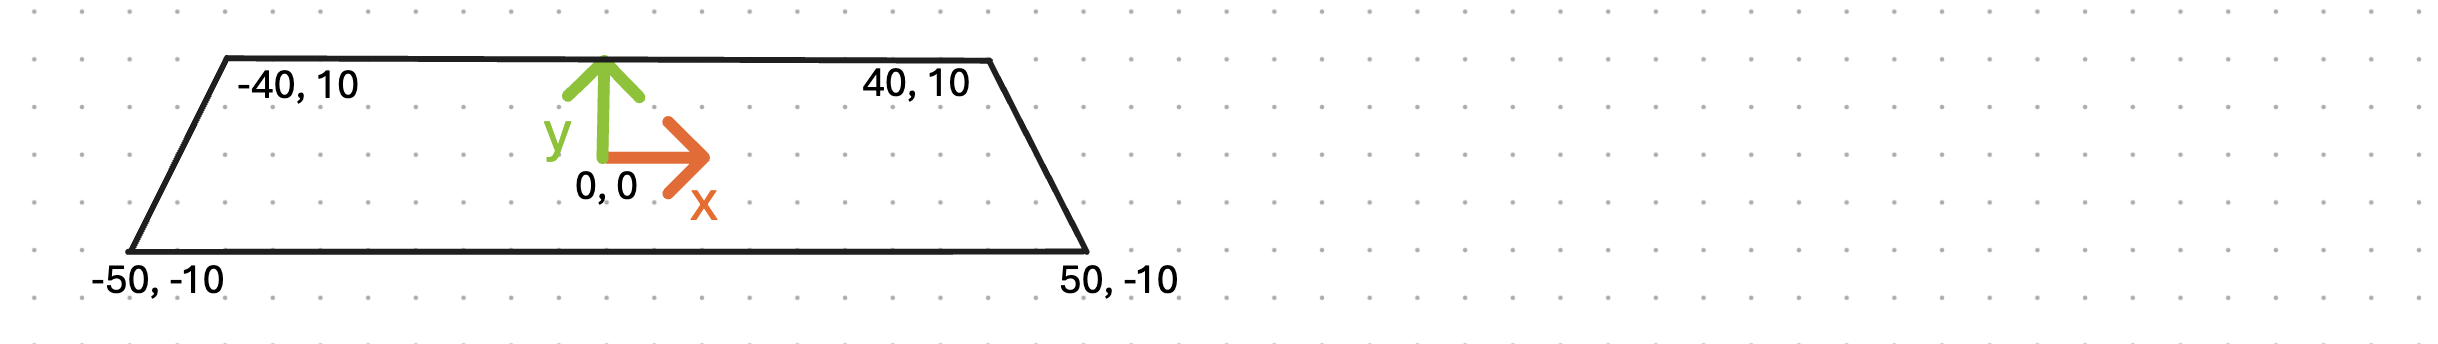

### Exercise

Use [pygame.draw.polygon](https://www.pygame.org/docs/ref/draw.html#pygame.draw.polygon) to draw the drone such that its center is at the coordinates of the drone, but for the moment assume that the rotation is 0 so the drone is upright.  Do do that:
- define the 4 points of the polygon, in meters.
- add the x,y coordinates of the desired center (in meters) to all 4 points.  This is the same as translating the polygon.
- use the existing function `to_pixel_coords(x,y)` on each of the 4 points to transform it to pixel coordinates.
- call `pygame.draw.polygon`

Draw the polygon for the drone filled in gray.

### How to rotate a set of points

We now want to rotate the drone around its center (i.e. the origin of the drone frame) by a given angle. How to do that?
Given a point at coordinates $(x,y)$, we can rotate it counterclockwise around (0,0)) by an angle $\theta$ to obtain a rotated point $(x', y')$ as follows:

$$
x' = x \cdot \cos(\theta) + y \cdot -\sin(\theta)
$$

$$
y' = x \cdot \sin(\theta) + y \cdot \cos(\theta)
$$

[This nice short video](https://youtu.be/7j5yW5QDC2U) explains why.


In [ ]:
import numpy as np
def rotate_point_around_origin(x,y,theta):
    return (
        x * np.cos(theta) + y * -1 * np.sin(theta),
        x * np.sin(theta) + y *      np.cos(theta)
    )

In [1]:
theta = np.deg2rad(10)
points = [(-.5,-.1), (+.5,-.1), (+.4,+.1), (-.4,+.1), (-.5,-.1)]
rotated_points = []
for x,y in points:
    rx, ry = rotate_point_around_origin(x,y,theta)
    rotated_points.append((rx,ry))

# Make a test drawing
import matplotlib.pyplot as plt
plt.plot(0,0,'go')
plt.plot(np.array(points)[:,0], np.array(points)[:,1], 'ko-')
plt.plot(np.array(rotated_points)[:,0], np.array(rotated_points)[:,1], 'bx-')
plt.axis("equal")


NameError: name 'np' is not defined

### Exercise

Fix your `drawOnSurface` function such that you can draw the drone rotated properly.  To do that:
- define the 4 points of the polygon, in meters.
- **rotate all 4 points according to `theta` (new)**.  This rotates the polygon
- add the x,y coordinates of the desired center (in meters) to all 4 rotated points.  This is the same as translating the polygon.
- use the existing function `to_pixel_coords(x,y)` on each of the 4 points to transform it to pixel coordinates.
- call `pygame.draw.polygon`

### Exercise

Let's now draw both the drone and the flame representing the thrust. That will be two calls to `polygon`: the first draws the drone, the second the flame (with a yellow fill and no polygon border).  Scale the length of the flame from 0 to 40 cm, based on the value of thrust (which ranges from 0 to 1).

Test your function and make sure that the drone behaves and displays as expected.

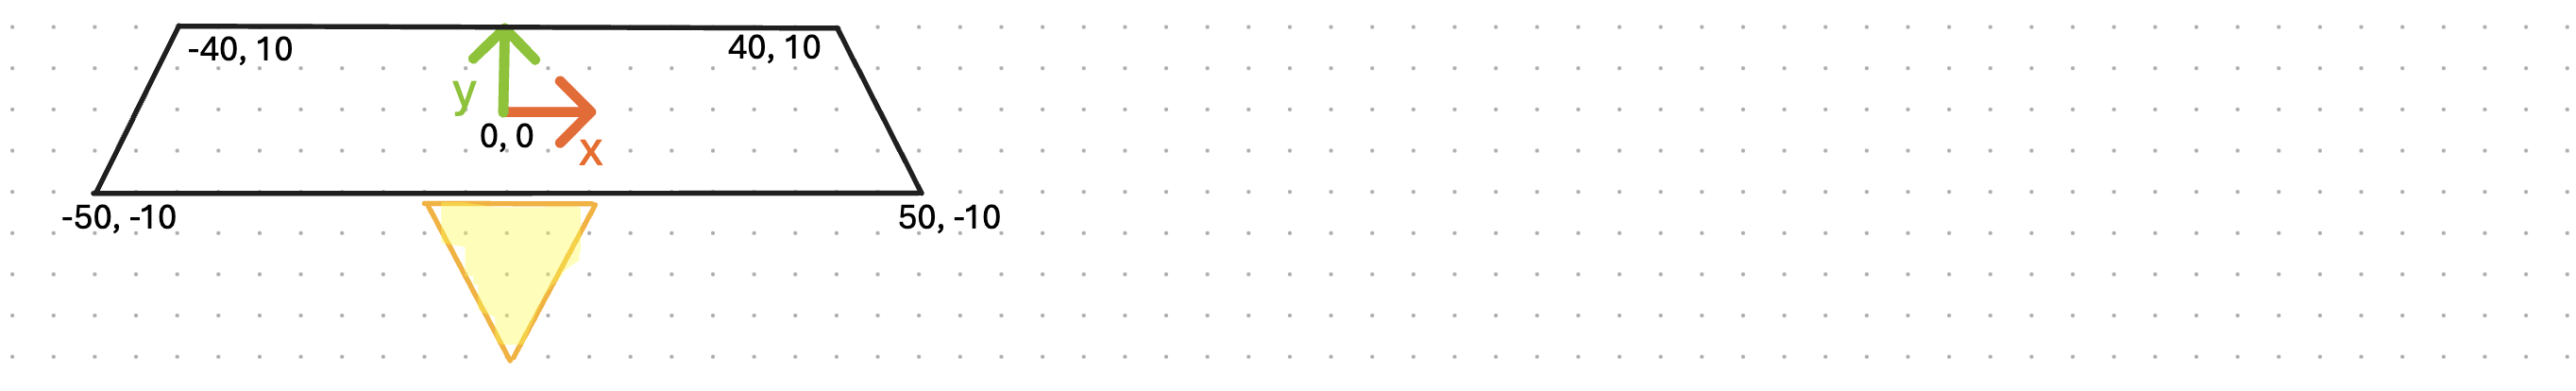

## Control part 1: controlling an upright drone to stay at a given height

### Exercise: manual control
Simulate a drone starting in the following state:
- `theta = 0`
- `omega = 0`
- `x = 0`
- `y = -1`
- `vx = 0`
- `vy = 0`

Try to control the drone with the keyboard (`w` key fires the thruster at maximum power, releasing it stops the thruster) in order to reach the target position (0,0) and stay hovering there.

To help yourself, draw a small square centered in (0,0), which will show clearly what is our target.

Make sure that:
- the simulation works as expected
- the inputs work as expected
- the state of the thruster is visualized properly

You should be able to solve the problem quite well

### Setting up a controller

Let's define a `Controller` class that controls the drone thruster to reach a given state.  It takes as input part of the state of the drone (`x`,`y`,`theta`), and produces as output the proportion of thrust (a float between 0 and 1).  This specific controller is a Bang Bang controller that pushes up at maximum force if the drone is below its target height, and turns the thruster off if we are above the target height.

In [ ]:
class Controller():
    def __init__(self):
        pass

    def step(self, 
             x, y, theta, 
             dt):        

        if y<0:
            thrust = 1
        else:
            thrust = 0

        return thrust # Between 0 and 1

### Exercise

Modify the `pygame_test` as follows:
- instantiate a `Controller` at the beginning
- in the main loop, before calling `Drone.step`, call `Controller.step` passing the current state of the drone
- take the output thrust and pass it to `Drone.step`.

Observe the behavior of the drone.